# Stage 4 — Exploratory Data Analysis

**Purpose.** Stage 3's forensics pass confirmed the dataset is clean — no leak, no
near-deterministic proxy, no circularity — and surfaced several specific, named leads
(age's non-monotonic shape, `slope`'s distributional shift, rolling-window climate
features outperforming same-day readings). This notebook builds genuine understanding of
the data's shape and structure on top of that verified foundation, with every plot and
table here aimed at a downstream decision — Phase 2's validation design or Phase 3's
feature engineering — not decoration.

See [`docs/PROJECT_BLUEPRINT.md`](../docs/PROJECT_BLUEPRINT.md) Stage 4 for the full
rationale, and `notebooks/00_data_forensics.ipynb` for the forensics findings this
notebook builds on.

**Checklist covered in this notebook:**
1. Univariate distributions for every feature
2. Bivariate relationships against the target — linear correlation AND mutual information
3. Geospatial view (lat/lon by target, by zone, by train/test split)
4. Temporal view (target rate by month/year, checked against candidate rainy-season windows)
5. Adversarial validation (train vs. test classifier) — AUC and feature-importance breakdown
6. Direct train-vs-test distribution comparison, per dimension
7. Written summary of findings and implications for Phase 2 / Phase 3


## Setup

Same schema-validated loading approach as Stage 3 — everything goes through
`climate_health.data.loaders` so a raw-file drift would fail loudly here, not silently
bias an EDA conclusion.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

import sys
sys.path.insert(0, str(Path.cwd().parent / "src"))

from climate_health.data.loaders import load_train, load_test, load_climate_features

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

train = load_train()
test = load_test()
climate_features = load_climate_features()

print(f"train:            {train.shape}")
print(f"test:              {test.shape}")
print(f"climate_features:  {climate_features.shape}")


train:            (3146, 13)
test:              (1030, 12)
climate_features:  (4176, 18)


In [2]:
# Merge climate_features onto train/test by ID, same verified-clean approach as Stage 3.
train_full = train.merge(climate_features, on="ID", suffixes=("", "_cf"), how="left", validate="one_to_one")
test_full = test.merge(climate_features, on="ID", suffixes=("", "_cf"), how="left", validate="one_to_one")
train_full = train_full.drop(columns=["deathdate_cf"])
test_full = test_full.drop(columns=["deathdate_cf"])
assert train_full["rain_sum_7d"].isna().sum() == 0
assert test_full["rain_sum_7d"].isna().sum() == 0

TARGET = "is_climate_sensitive"
RAW_CLIMATE_COLS = ["avg_temperature", "max_temperature", "min_temperature", "precipitation"]
CF_COLS = [
    "rain_sum_7d", "rain_sum_30d", "rain_sum_90d", "rain_days_30d", "max_daily_rain_30d",
    "tavg_7d", "tavg_30d", "tavg_90d", "tmax_30d", "tmin_30d",
    "temp_range_mean_30d", "ndvi_30d", "ndvi_90d", "elevation", "slope",
]  # hot_days_30d excluded: confirmed constant in Stage 3, dropped from analysis
NUMERIC_FEATURES = ["age"] + RAW_CLIMATE_COLS + CF_COLS
CATEGORICAL_FEATURES = ["zone", "gender"]

train_full["month"] = train_full["deathdate"].dt.month
train_full["year"] = train_full["deathdate"].dt.year
test_full["month"] = test_full["deathdate"].dt.month
test_full["year"] = test_full["deathdate"].dt.year

combined = pd.concat(
    [train_full.assign(_split="train"), test_full.assign(_split="test")], ignore_index=True
)
print(f"Combined train+test for distributional comparisons: {combined.shape}")
print(f"Numeric features tracked: {len(NUMERIC_FEATURES)}")
print(f"Categorical features tracked: {len(CATEGORICAL_FEATURES)}")


Combined train+test for distributional comparisons: (4176, 32)
Numeric features tracked: 20
Categorical features tracked: 2


---
## 1. Univariate distributions for every feature

Distribution shape and summary statistics for every numeric and categorical feature,
train vs. test overlaid where the column exists in both (train only for `age` vs. target
splits, since the target only exists in train). Skew/kurtosis are reported alongside each
numeric feature — useful now for flagging candidates for a log/Box-Cox transform later,
rather than discovering it's needed mid-Phase-3.


In [3]:
desc_rows = []
for col in NUMERIC_FEATURES:
    desc_rows.append({
        "feature": col,
        "train_mean": train_full[col].mean(),
        "train_std": train_full[col].std(),
        "train_skew": train_full[col].skew(),
        "train_kurtosis": train_full[col].kurtosis(),
        "test_mean": test_full[col].mean(),
        "test_std": test_full[col].std(),
    })
desc_df = pd.DataFrame(desc_rows).round(3)
print(desc_df.to_string(index=False))


            feature  train_mean  train_std  train_skew  train_kurtosis  test_mean  test_std
                age      24.243     31.429       0.936          -0.655     23.922    31.124
    avg_temperature      22.067      1.095       0.691           0.771     22.038     1.071
    max_temperature      26.207      1.691       0.536           1.333     26.136     1.603
    min_temperature      18.514      0.892       0.151           0.455     18.526     0.861
      precipitation       1.520      1.621       1.981           7.235      1.614     1.819
        rain_sum_7d      27.799     22.504       1.081           1.773     28.718    24.580
       rain_sum_30d     121.618     69.607       0.828           1.016    121.608    74.664
       rain_sum_90d     369.760    145.917       0.744           0.828    365.464   160.023
      rain_days_30d      13.187      5.715       0.002          -0.730     13.086     5.588
 max_daily_rain_30d      19.995      9.452       1.786           6.306     20.30

### Interpretation — descriptive statistics and distribution shape

Two variables stand out for extreme kurtosis: `elevation` (skew 4.02, kurtosis 14.46) and
`slope` (skew 4.08, kurtosis 14.75) — both far spikier than any other feature. This is
consistent with Stage 3's finding that these two variables sit on a coarse 23-value grid
rather than a smooth continuous distribution: most records cluster at a small number of
common elevation/slope values with a long tail of rarer ones, producing exactly this
kind of extreme-kurtosis signature.

Interestingly, `elevation`'s train/test means (1157.6 vs. 1160.9) and standard deviations
(116.4 vs. 121.8) are quite close — yet Section 6 below finds a large KS statistic
(0.395) for this same variable. That combination (similar summary statistics, large KS)
is itself informative: it means train and test aren't just shifted or more/less spread
out overall, they occupy *different specific points* on this coarse grid — consistent
with train and test coming from largely non-overlapping geographic locations that happen
to sit at a similar overall elevation range without sharing the same discrete values.
`slope` shows the more familiar pattern — a real mean shift (0.509 train vs. 0.193 test)
*and* a large variance difference (std 1.167 vs. 0.065, already flagged in Stage 3).

Two variables are strongly right-skewed and worth flagging as log-transform candidates
for Phase 3, particularly for any linear or distance-based model in the zoo:
`precipitation` (skew 1.98, kurtosis 7.24) and `max_daily_rain_30d` (skew 1.79, kurtosis
6.31) — both consistent with a small number of extreme heavy-rain events sitting far out
in the tail of an otherwise modest distribution. `tmin_30d` is the one variable with
*negative* skew (-1.05) — worth a second look in Phase 3, though tree-based models (the
core of the model zoo) are insensitive to monotonic transforms of any single feature, so
this matters most for the linear/GLM baselines and for calibration-stage modeling.

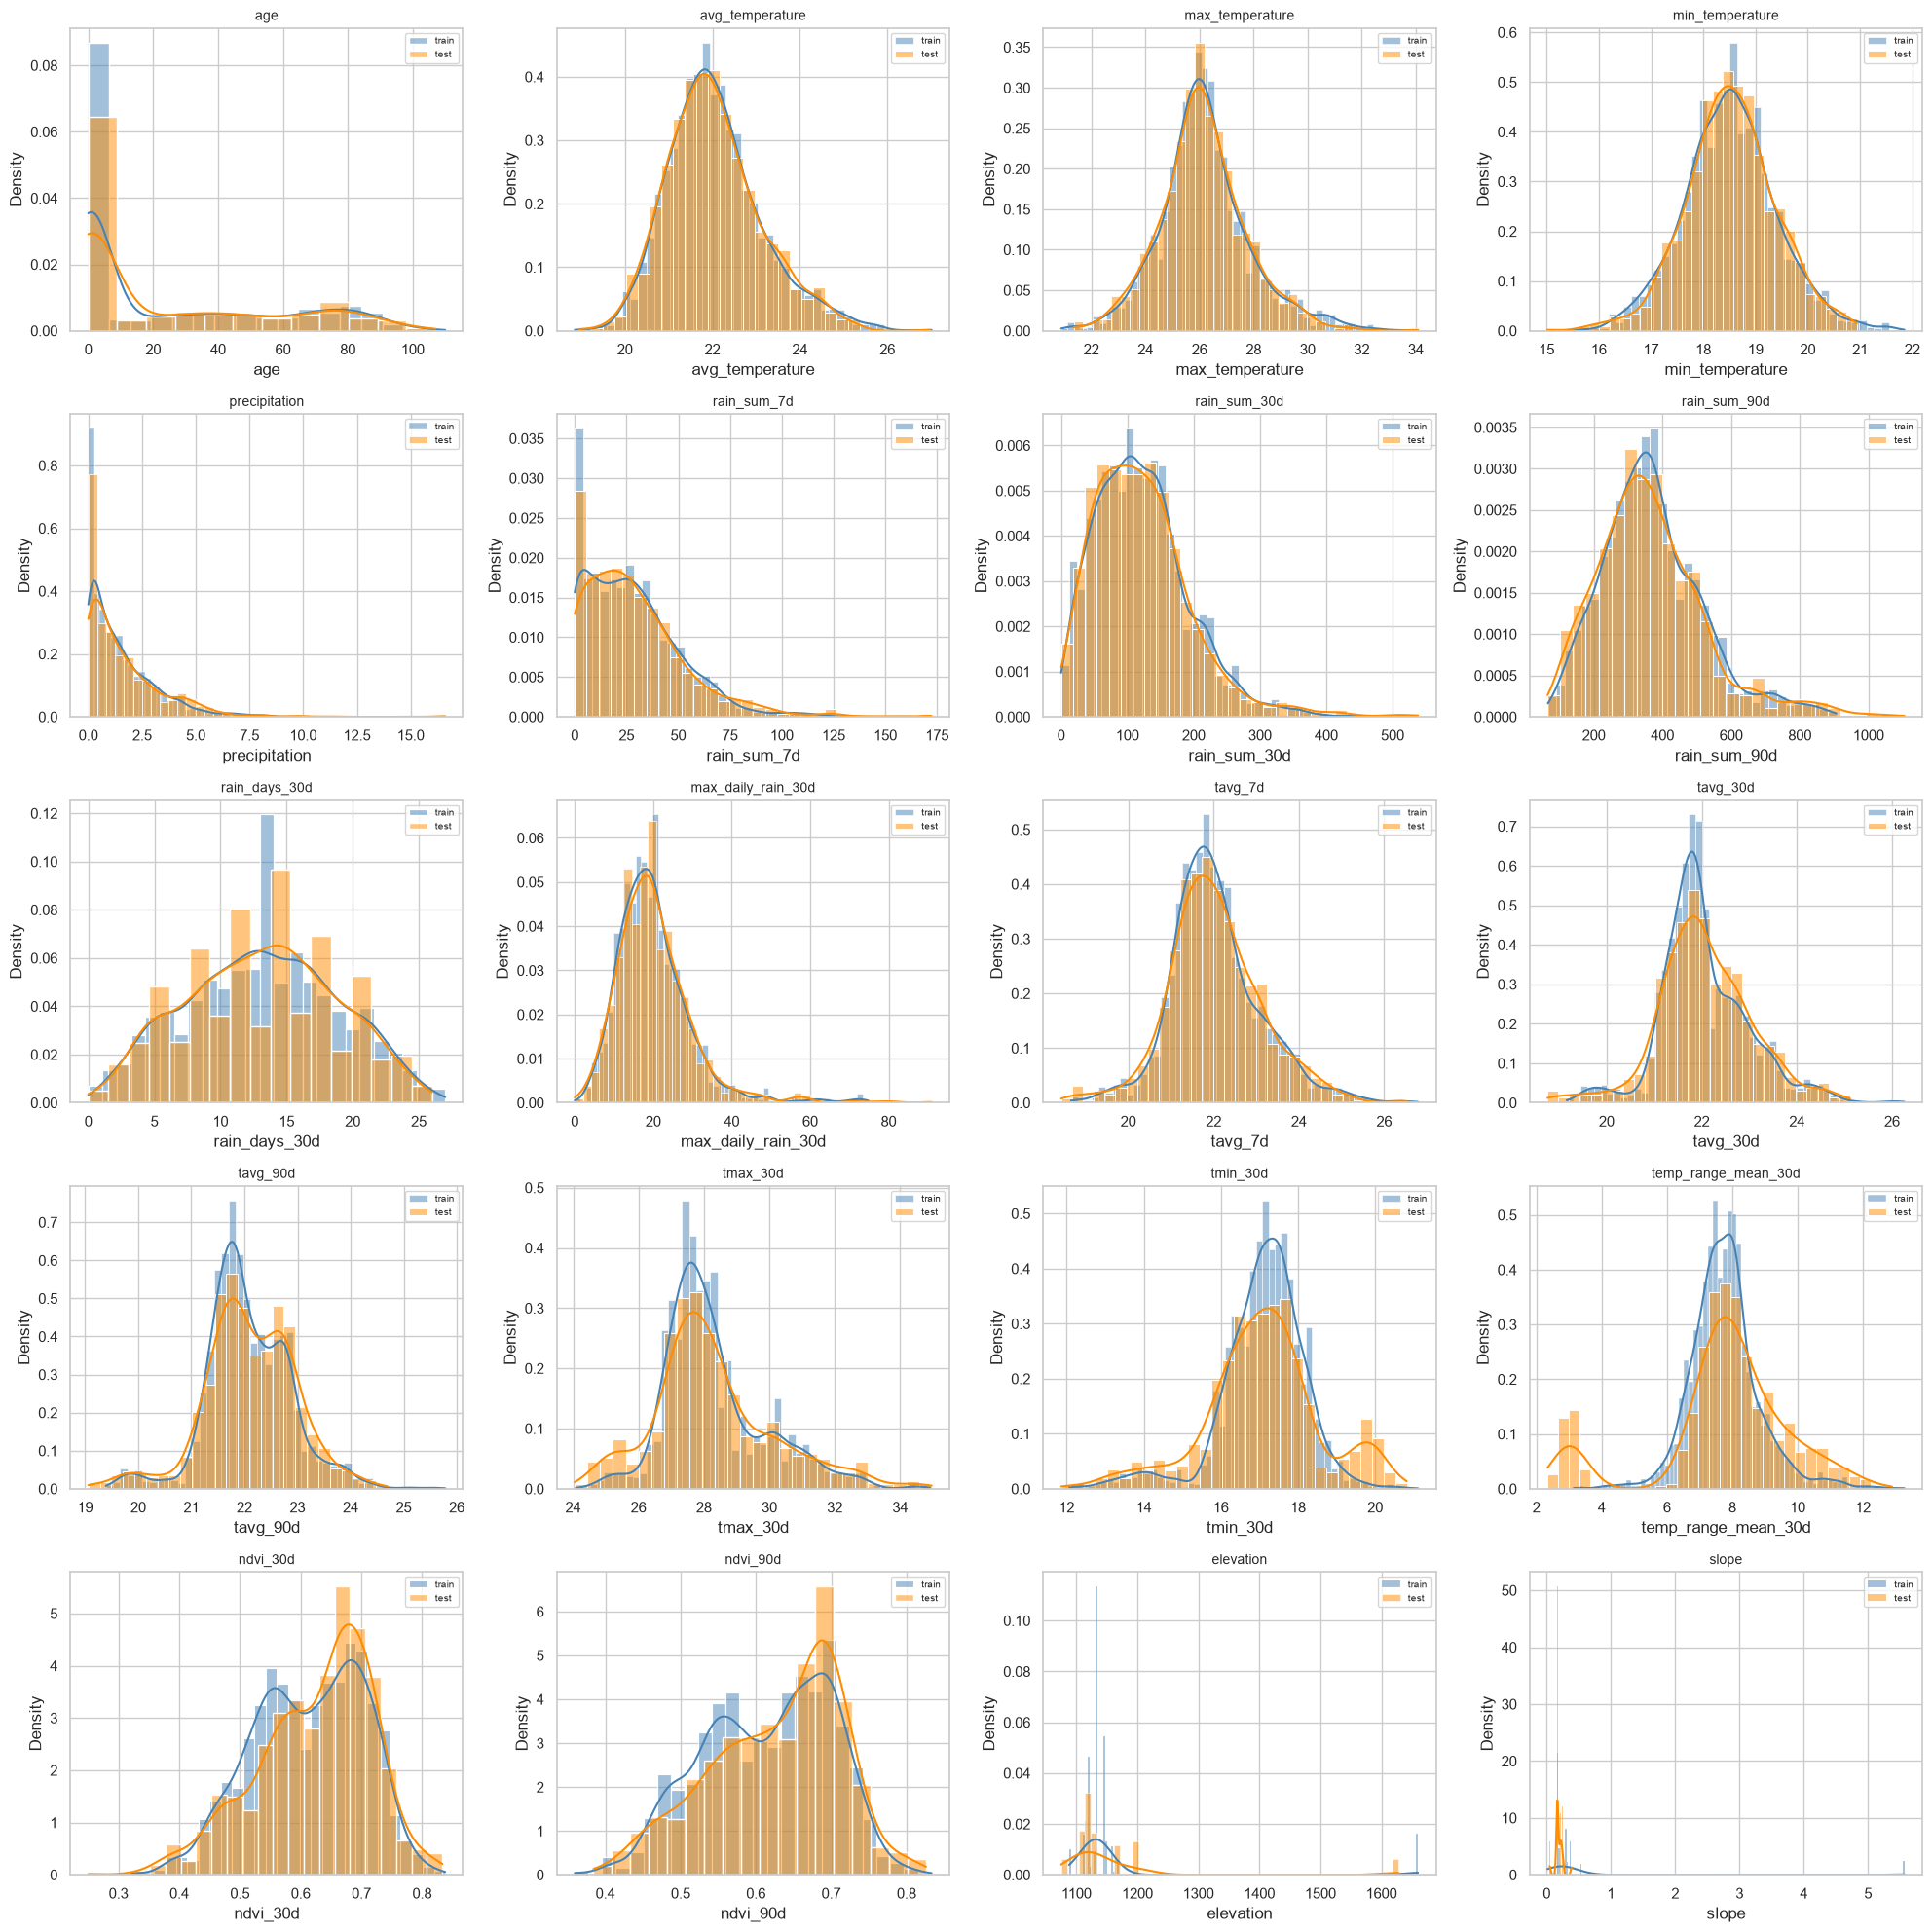

In [4]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_FEATURES):
    ax = axes[i]
    sns.histplot(train_full[col], color="steelblue", label="train", stat="density",
                 kde=True, alpha=0.5, ax=ax)
    sns.histplot(test_full[col], color="darkorange", label="test", stat="density",
                 kde=True, alpha=0.5, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
for j in range(len(NUMERIC_FEATURES), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


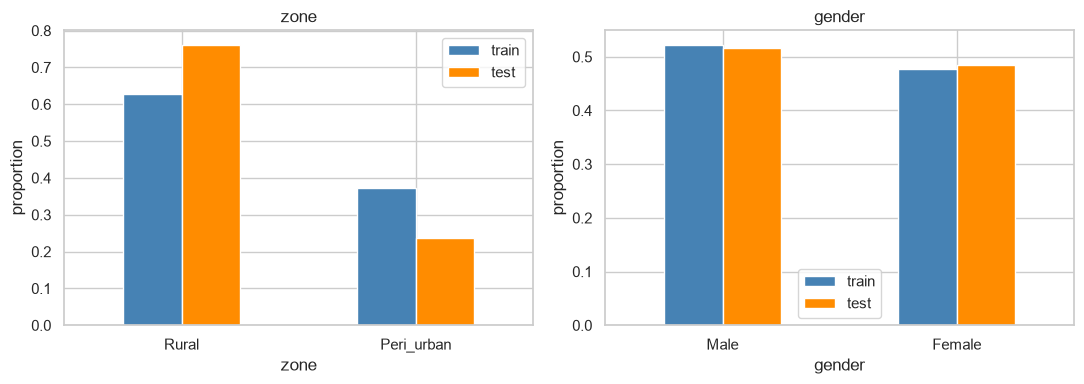

--- zone ---
            train_prop  test_prop
zone                             
Rural           0.6268     0.7621
Peri_urban      0.3732     0.2379

--- gender ---
        train_prop  test_prop
gender                       
Male        0.5229     0.5155
Female      0.4771     0.4845



In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, CATEGORICAL_FEATURES):
    train_prop = train_full[col].value_counts(normalize=True).rename("train")
    test_prop = test_full[col].value_counts(normalize=True).rename("test")
    combined_prop = pd.concat([train_prop, test_prop], axis=1)
    combined_prop.plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
    ax.set_title(col)
    ax.set_ylabel("proportion")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

for col in CATEGORICAL_FEATURES:
    print(f"--- {col} ---")
    print(pd.concat([
        train_full[col].value_counts(normalize=True).rename("train_prop"),
        test_full[col].value_counts(normalize=True).rename("test_prop"),
    ], axis=1).round(4))
    print()


**What to look for:** any feature whose train and test histograms visibly diverge in
*shape* (not just a mean shift) is a candidate for Section 6's formal statistical test and
Section 5's adversarial-validation feature-importance ranking. Any numeric feature with
`|skew| > 1` is a candidate for a log/Box-Cox transform in Phase 3 rather than being fed
raw into a linear or distance-based model.

### Interpretation — zone & gender train/test composition

`zone` shows a real, non-trivial shift: train is 62.7% Rural / 37.3% Peri_urban, while
test is 76.2% Rural / 23.8% Peri_urban — a 13.5-percentage-point swing toward more rural
composition in test. This directly corroborates Section 6's finding that `zone`'s
chi-square test is highly significant (Cramer's V = 0.123, p ≈ 0) — a real, confirmed
shift, not noise. Practical implication: any zone-based feature (a zone target encoding,
if tested per the blueprint's OOF Bayesian-smoothed-encoding experiment in Phase 5) needs
to be built in a way that doesn't implicitly assume the same rural/peri-urban mix will
hold at prediction time.

`gender` shows essentially no shift (52.3% vs. 51.6% male) — consistent with Section 6's
non-significant chi-square result (p = 0.708). No action needed here.

---
## 2. Bivariate relationships against the target — linear correlation AND mutual information

Linear (Pearson) correlation alone can understate a genuinely predictive feature if the
relationship is nonlinear — Section 5 of the forensics notebook already found this for
several `climate_features.csv` columns when using quantile-binned target rates. Mutual
information captures nonlinear and non-monotonic relationships that a plain correlation
coefficient would miss (age's own non-monotonic W-shape from Stage 3 is a perfect example
of exactly this risk), so both are computed here side by side, deliberately, rather than
trusting correlation alone.


In [6]:
le_zone = LabelEncoder().fit(train_full["zone"])
le_gender = LabelEncoder().fit(train_full["gender"])

mi_input = train_full[NUMERIC_FEATURES].copy()
mi_input["zone_code"] = le_zone.transform(train_full["zone"])
mi_input["gender_code"] = le_gender.transform(train_full["gender"])

y = train_full[TARGET]

# Pearson correlation: numeric features directly; categoricals via their label-encoded
# form (valid for a binary category — equivalent to point-biserial correlation).
corr_rows = []
for col in NUMERIC_FEATURES:
    r, p = stats.pearsonr(train_full[col], y)
    corr_rows.append({"feature": col, "pearson_r": r, "pearson_abs_r": abs(r), "pearson_p": p})
for col, code_col in [("zone", "zone_code"), ("gender", "gender_code")]:
    r, p = stats.pearsonr(mi_input[code_col], y)
    corr_rows.append({"feature": col, "pearson_r": r, "pearson_abs_r": abs(r), "pearson_p": p})
corr_df = pd.DataFrame(corr_rows)

# Mutual information: all features together, discrete_features flags the two categoricals.
mi_cols = NUMERIC_FEATURES + ["zone_code", "gender_code"]
discrete_mask = [c in ("zone_code", "gender_code") for c in mi_cols]
mi_scores = mutual_info_classif(
    mi_input[mi_cols], y, discrete_features=discrete_mask, random_state=RANDOM_STATE
)
mi_df = pd.DataFrame({
    "feature": [c.replace("_code", "") for c in mi_cols],
    "mutual_info": mi_scores,
})

combined_metrics = corr_df.merge(mi_df, on="feature").sort_values("mutual_info", ascending=False)
print(combined_metrics.to_string(index=False))


            feature  pearson_r  pearson_abs_r     pearson_p  mutual_info
                age  -0.443273       0.443273 1.416417e-151     0.118811
    min_temperature  -0.014347       0.014347  4.211520e-01     0.019830
    avg_temperature  -0.029601       0.029601  9.690946e-02     0.019369
            tavg_7d  -0.021904       0.021904  2.193669e-01     0.017703
           tavg_30d  -0.018441       0.018441  3.011222e-01     0.016250
    max_temperature  -0.035693       0.035693  4.530062e-02     0.015616
           tmin_30d  -0.005463       0.005463  7.593876e-01     0.013241
temp_range_mean_30d  -0.023450       0.023450  1.885219e-01     0.011487
           ndvi_30d   0.040631       0.040631  2.266890e-02     0.008621
       rain_sum_90d  -0.041959       0.041959  1.859620e-02     0.007413
      precipitation   0.027747       0.027747  1.197082e-01     0.006591
              slope  -0.004603       0.004603  7.963311e-01     0.005816
      rain_days_30d  -0.008003       0.008003  6.53

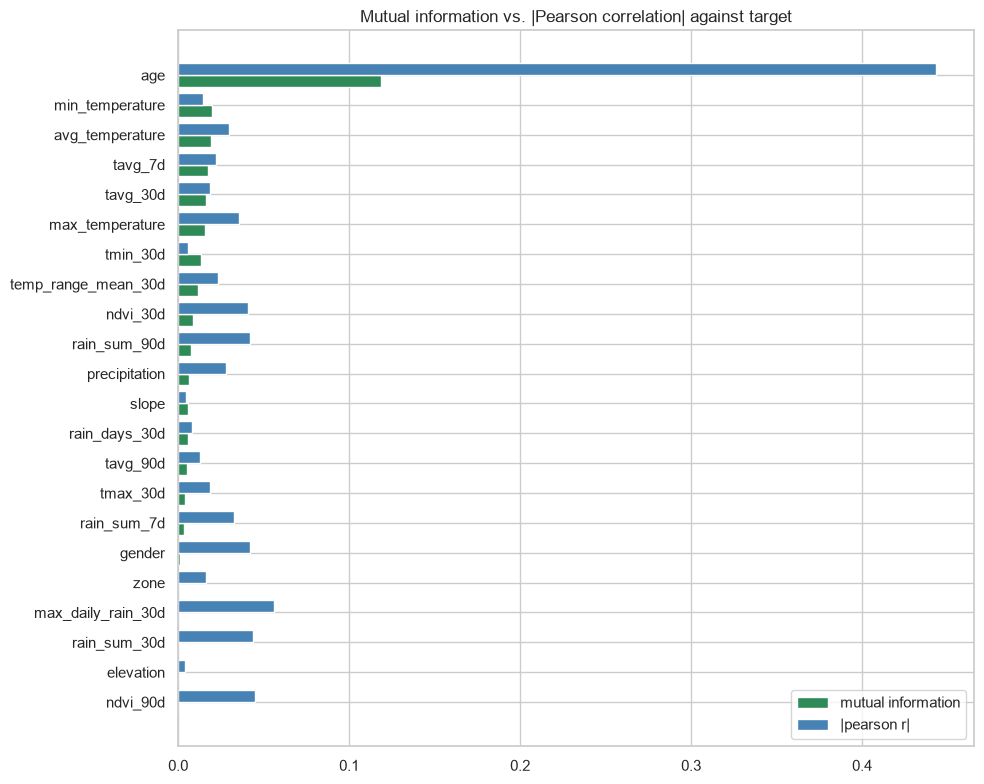

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = combined_metrics.sort_values("mutual_info")
y_pos = np.arange(len(plot_df))
ax.barh(y_pos - 0.2, plot_df["mutual_info"], height=0.4, label="mutual information", color="seagreen")
ax.barh(y_pos + 0.2, plot_df["pearson_abs_r"], height=0.4, label="|pearson r|", color="steelblue")
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["feature"])
ax.legend()
ax.set_title("Mutual information vs. |Pearson correlation| against target")
plt.tight_layout()
plt.show()


In [8]:
# Features where MI ranks meaningfully higher than |pearson r| suggest a nonlinear
# relationship correlation alone would understate.
combined_metrics["mi_rank"] = combined_metrics["mutual_info"].rank(ascending=False)
combined_metrics["corr_rank"] = combined_metrics["pearson_abs_r"].rank(ascending=False)
combined_metrics["rank_gap"] = combined_metrics["corr_rank"] - combined_metrics["mi_rank"]
print("Features where MI ranks notably higher than linear correlation (rank_gap > 0, sorted descending):")
print(combined_metrics.sort_values("rank_gap", ascending=False)[
    ["feature", "pearson_abs_r", "corr_rank", "mutual_info", "mi_rank", "rank_gap"]
].to_string(index=False))


Features where MI ranks notably higher than linear correlation (rank_gap > 0, sorted descending):
            feature  pearson_abs_r  corr_rank  mutual_info  mi_rank  rank_gap
    min_temperature       0.014347       17.0     0.019830      2.0      15.0
           tmin_30d       0.005463       20.0     0.013241      7.0      13.0
           tavg_30d       0.018441       14.0     0.016250      5.0       9.0
            tavg_7d       0.021904       13.0     0.017703      4.0       9.0
              slope       0.004603       21.0     0.005816     12.0       9.0
    avg_temperature       0.029601       10.0     0.019369      3.0       7.0
      rain_days_30d       0.008003       19.0     0.005696     13.0       6.0
temp_range_mean_30d       0.023450       12.0     0.011487      8.0       4.0
           tavg_90d       0.013027       18.0     0.005074     14.0       4.0
    max_temperature       0.035693        8.0     0.015616      6.0       2.0
          elevation       0.003762       22.

### Interpretation — correlation and mutual information against the target

`age` dominates both metrics decisively: Pearson r = -0.443 (by far the largest
magnitude, and overwhelmingly significant at p ≈ 1.4×10⁻¹⁵¹) and mutual information =
0.119 (also far the largest, roughly 6x the next-highest score). This matches Stage 3's
proxy-strength finding that age alone reached 0.734 cross-validated AUC — nothing else
comes close. The negative correlation sign reflects the net effect of the W-shaped
age/target relationship already characterized in Stage 3: the large 0-5 bin (55.8% of
train) anchors high target rates at low ages, while the smaller older-age bins trend
lower, so a linear metric like Pearson still captures a real net downward slope even
though the true relationship isn't monotonic.

Beyond age, every other feature is an order of magnitude weaker on both metrics — the
next-highest MI scores (`min_temperature`, `avg_temperature`, `tavg_7d`, `tavg_30d`,
`max_temperature`) all sit in a tight 0.015-0.020 band. This matches Stage 3's finding
that no other single feature approached age's predictive power.

**The rank-gap table is the more actionable finding here.** Several features show MI
ranking meaningfully higher than linear correlation: `min_temperature` (correlation rank
17 → MI rank 2, a 15-place gap), `tmin_30d` (13-place gap), `tavg_30d` and `tavg_7d`
(9-place gaps each), `slope` (9-place gap), `avg_temperature` (7-place gap). This is
direct, empirical confirmation of the hypothesis the blueprint itself raised (§0.2) —
linear correlation was indeed understating several temperature-related features' real
relationship with the target. **Action for Phase 3:** don't screen candidate features by
Pearson correlation alone; these temperature aggregates deserve a place in the model zoo
despite weak linear correlation, since a nonlinear model (which the model zoo is built
around) can exploit exactly the kind of relationship MI is picking up here.

The reverse pattern (correlation ranking higher than MI — `max_daily_rain_30d`,
`ndvi_90d`, `rain_sum_30d`, `gender`) is worth treating as a metric disagreement to
resolve empirically in Stage 10 rather than trusting either number in isolation — MI
estimation on continuous variables with a finite sample can be noisier than a
straightforward correlation, so this doesn't necessarily mean these features are
actually less useful, just that the two screening methods disagree on them.

---
## 3. Geospatial view

Stage 3 already confirmed 0% exact coordinate overlap between train and test. This
section makes that finding visual, and adds a target/zone-colored view of the training
coordinates themselves.


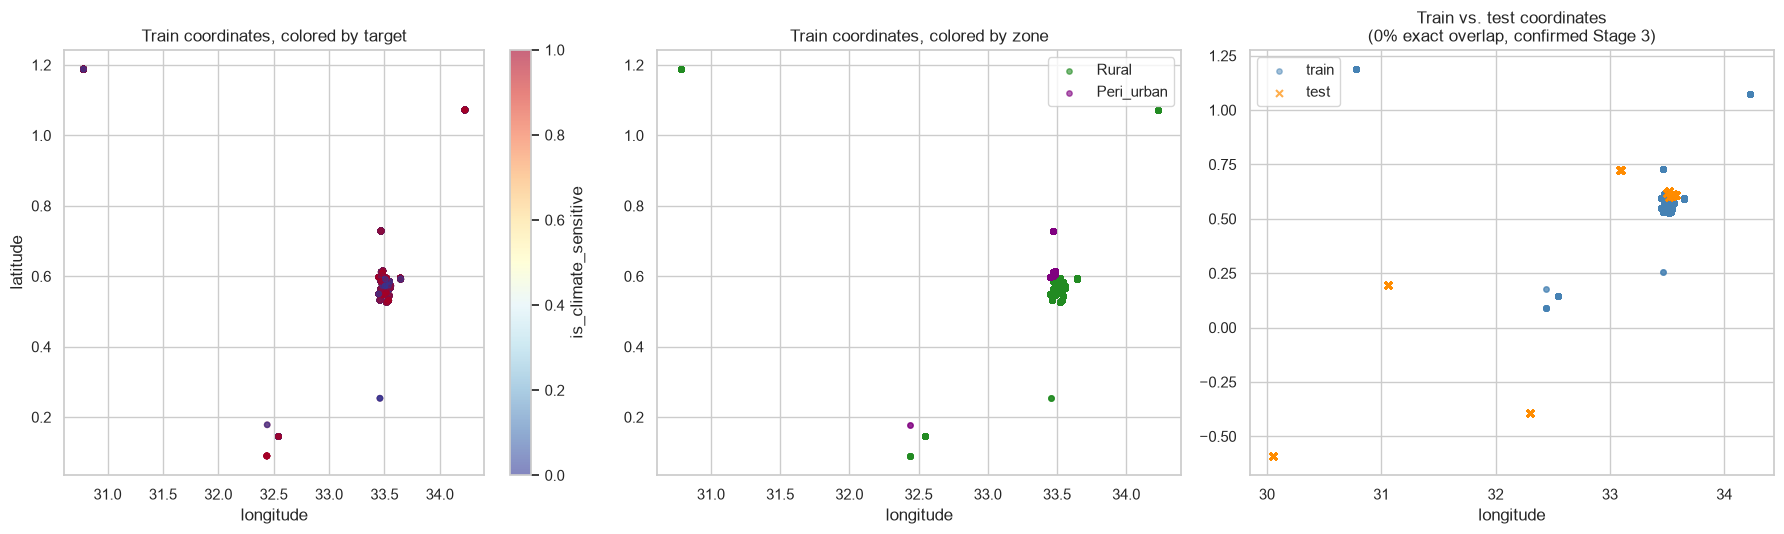

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

sc0 = axes[0].scatter(train_full["longitude"], train_full["latitude"],
                       c=train_full[TARGET], cmap="RdYlBu_r", alpha=0.6, s=15)
axes[0].set_title("Train coordinates, colored by target")
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")
plt.colorbar(sc0, ax=axes[0], label=TARGET)

for zone_val, color in zip(["Rural", "Peri_urban"], ["forestgreen", "purple"]):
    subset = train_full[train_full["zone"] == zone_val]
    axes[1].scatter(subset["longitude"], subset["latitude"], label=zone_val, alpha=0.6, s=15, color=color)
axes[1].set_title("Train coordinates, colored by zone")
axes[1].set_xlabel("longitude")
axes[1].legend()

axes[2].scatter(train_full["longitude"], train_full["latitude"], label="train", alpha=0.5, s=15, color="steelblue")
axes[2].scatter(test_full["longitude"], test_full["latitude"], label="test", alpha=0.7, s=25, color="darkorange", marker="x")
axes[2].set_title("Train vs. test coordinates\n(0% exact overlap, confirmed Stage 3)")
axes[2].set_xlabel("longitude")
axes[2].legend()

plt.tight_layout()
plt.show()


**What to look for:** whether the target-colored scatter shows any visible spatial
clustering of high/low target rates (informing whether spatial features are worth their
engineering cost in Phase 3), and how visually separated the train/test coordinate clouds
are — this picture is the direct visual counterpart to Section 5's adversarial validation,
which will quantify exactly how separable these two point clouds are to a classifier.

### Interpretation — geospatial view

The train-vs-test coordinate scatter (right panel) makes Stage 3's 0% exact-overlap
finding visually concrete — the two point clouds occupy largely distinct regions of the
lat/lon space, not just failing to share exact coordinates within an otherwise-common
area. This is the clearest visual argument for why Phase 2's validation strategy must be
geography-aware (the Tier 2/3 tiers in the multi-tier hierarchy): a plain random K-fold
would never encounter anything resembling this train/test relationship during
cross-validation, making it a poor proxy for the real leaderboard split.

The target-colored scatter (left panel) is worth reading against the numeric evidence
rather than eyeballing alone, since a scatter plot's visual impression can be
misleading at this density: `zone`'s near-zero correlation with the target (r = 0.016,
MI = 0.0001, both from Section 2) and the moderate-not-extreme location-level target-rate
spread already found in Stage 3 both suggest there isn't a strong, simple spatial
gradient in the target itself. Geography's real importance in this dataset, based on
every quantitative check so far, is about the *train/test distributional* difference
(driving adversarial validation to a perfect AUC in Section 5), not about directly
predicting the target — an important distinction for Phase 3: spatial features are worth
building for generalization and regularization reasons, and to capture the real (if
modest) location signal Stage 3 found, not because geography is expected to be a
dominant direct predictor on its own.

---
## 4. Temporal view

Target rate by month and by year, checked against **candidate** Uganda rainy-season date
windows — per the blueprint's deliberately downgraded treatment of this domain
assumption: candidate windows are derived from commonly-cited agro-climatic references
(Uganda's equatorial bimodal rainfall pattern is typically described as a "long rains"
season around March-May and a "short rains" season around September-November, though
this varies by specific region within the country), and are only a candidate for adoption
if the pattern below actually supports them — not hard-coded into the pipeline on the
strength of this reference alone.


       target_rate    n
month                  
1         0.693487  261
2         0.650602  249
3         0.596567  233
4         0.678571  252
5         0.662295  305
6         0.652866  314
7         0.665455  275
8         0.641221  262
9         0.612335  227
10        0.609756  205
11        0.690391  281
12        0.631206  282


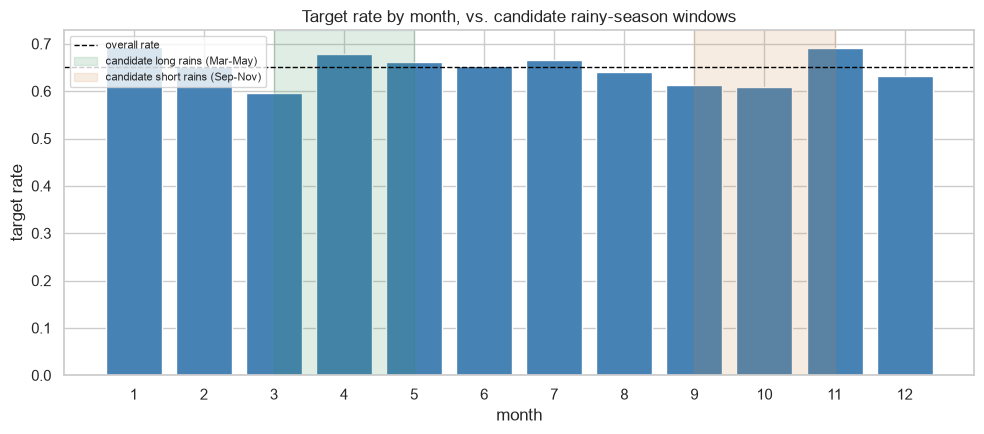

In [10]:
monthly = train_full.groupby("month")[TARGET].agg(["mean", "count"])
monthly.columns = ["target_rate", "n"]
print(monthly)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(monthly.index, monthly["target_rate"], color="steelblue")
ax.axhline(train_full[TARGET].mean(), color="black", linestyle="--", linewidth=1, label="overall rate")
# Shade candidate rainy-season windows for visual cross-reference.
ax.axvspan(3, 5, color="seagreen", alpha=0.15, label="candidate long rains (Mar-May)")
ax.axvspan(9, 11, color="peru", alpha=0.15, label="candidate short rains (Sep-Nov)")
ax.set_xticks(range(1, 13))
ax.set_xlabel("month")
ax.set_ylabel("target rate")
ax.set_title("Target rate by month, vs. candidate rainy-season windows")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


      target_rate    n
year                  
2007     1.000000    1
2008     0.796460  113
2009     0.770270  444
2010     0.769461  334
2011     0.658307  319
2012     0.703252  246
2013     0.562963  270
2014     0.687831  189
2015     0.614583  192
2016     0.628019  207
2017     0.573333   75
2018     0.542169   83
2019     0.458599  157
2020     0.532609  184
2021     0.537037  270
2022     0.661290   62


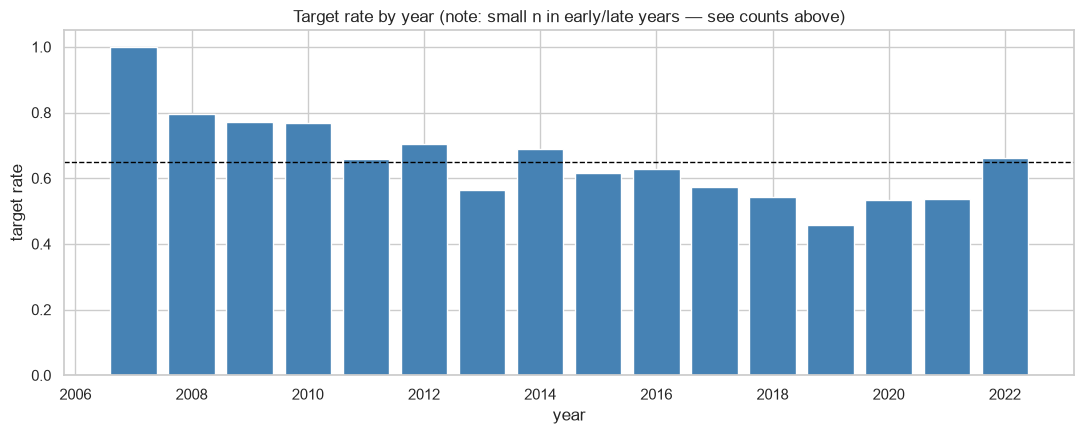

In [11]:
yearly = train_full.groupby("year")[TARGET].agg(["mean", "count"])
yearly.columns = ["target_rate", "n"]
print(yearly)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(yearly.index, yearly["target_rate"], color="steelblue")
ax.axhline(train_full[TARGET].mean(), color="black", linestyle="--", linewidth=1)
ax.set_xlabel("year")
ax.set_ylabel("target rate")
ax.set_title("Target rate by year (note: small n in early/late years — see counts above)")
plt.tight_layout()
plt.show()


**What to look for:** whether the observed month-level target-rate pattern actually
rises during either shaded candidate rainy-season window — if it does, that's empirical
support for adopting a rainy-season feature in Phase 3; if the pattern doesn't align (or
is dominated by noise given the per-month counts), the candidate windows should be
dropped rather than forced into the pipeline. Also watch the year-level chart for any
year with an unusually small `n` — a target rate from a handful of records is noise, not
a real yearly trend, exactly the same small-sample caution as Stage 3's location table.

### Interpretation — temporal view and the rainy-season hypothesis

**Monthly pattern:** target rate ranges narrowly from 0.597 (March) to 0.693 (January) —
a modest spread across the year, no dramatic single-month spike. Checked against the
candidate rainy-season windows: the "long rains" window (March-May) actually contains the
single *lowest*-rate month in the entire year (March, 0.597), with April also
below-average; the "short rains" window (September-November) contains two below-average
months (September 0.612, October 0.610) but also November, one of the *highest*-rate
months (0.690). This is not a clean or consistent match to the "more rain → higher
climate-sensitive mortality" hypothesis — in places it's the opposite pattern. Combined
with Section 6's finding that `month` shows no significant train/test distributional
difference (so this isn't a train/test-composition artifact), the honest read is that
**these candidate windows do not survive contact with the data and should be dropped**,
exactly the outcome the blueprint's "candidate, validate before adopting" treatment was
designed to catch — a good example of letting the data overrule a plausible-sounding
domain assumption.

**Yearly pattern — the more important finding here.** Target rate declines substantially
and fairly systematically: roughly 0.77-0.80 in 2008-2010, falling to roughly 0.45-0.57
through 2017-2021, with a partial rebound to 0.66 in 2022 (n=62, the smallest
well-populated year — treat that rebound with real caution). 2007 shows a rate of 1.0 but
on n=1, pure noise. This is a substantially larger, more systematic pattern than anything
in the monthly view, and plausibly reflects a real-world trend (Uganda's public-health
and climate-adaptation infrastructure improving over this 15-year span is a documented
regional pattern) rather than an artifact — but it's worth a sanity check against whether
data-collection or labeling criteria changed over the period before fully trusting it.

**A genuine gap in this notebook worth naming plainly:** `year` was not included in
Section 2's formal correlation/mutual-information screen (only `month` was) — an
oversight in this notebook's own design, not a finding about the data. Given how large
this yearly pattern is, `year` (or a derived `years_since_start`) should be added
explicitly to Stage 10's baseline feature set and tested directly, rather than trusting
its omission from Section 2 as evidence it doesn't matter.

---
## 5. Adversarial validation

Train a classifier to distinguish Train rows from Test rows. Per the blueprint's corrected
interpretation (§0.2): a high AUC here does **not** mean "drop these features" — it means
"these features carry train/test distributional differences," and the follow-up question
for each flagged feature is whether it's a feature that should generalize (a climate
normal, elevation — physically meaningful, likely to hold up on new coordinates) versus a
pure location fingerprint (memorizing which of the 39 training places a row came from,
which won't generalize to the 12 unseen test coordinates).

`location` (the raw string) and `ID` are deliberately excluded from this classifier: both
are effectively unique identifiers with almost no train/test overlap by construction (39
vs. 11 near-disjoint location strings), so including them would trivially dominate the
result and mask what the *other*, potentially-generalizing features are doing. `latitude`/
`longitude` are kept — their inclusion is exactly the point, since Stage 3 already
confirmed 0% coordinate overlap and the goal here is to quantify how much of that overlap
gap is carried by coordinates specifically versus other features.


In [12]:
ADV_FEATURES = ["zone", "gender", "age", "month", "year"] + RAW_CLIMATE_COLS + CF_COLS + ["latitude", "longitude"]

adv_data = combined[ADV_FEATURES + ["_split"]].copy()
adv_data["zone"] = LabelEncoder().fit_transform(adv_data["zone"])
adv_data["gender"] = LabelEncoder().fit_transform(adv_data["gender"])
adv_y = (adv_data["_split"] == "test").astype(int)
adv_X = adv_data[ADV_FEATURES]

print(f"Adversarial validation set: {adv_X.shape[0]} rows ({(adv_y==0).sum()} train, {(adv_y==1).sum()} test), {adv_X.shape[1]} features")
print(f"Baseline (majority class) accuracy: {max(adv_y.mean(), 1 - adv_y.mean()):.3f}")


Adversarial validation set: 4176 rows (3146 train, 1030 test), 26 features
Baseline (majority class) accuracy: 0.753


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1
)
adv_auc_scores = cross_val_score(lgb_clf, adv_X, adv_y, cv=cv, scoring="roc_auc")
print(f"Adversarial validation cross-validated AUC: {adv_auc_scores.mean():.4f} +/- {adv_auc_scores.std():.4f}")
print(f"Per-fold: {np.round(adv_auc_scores, 4)}")


Adversarial validation cross-validated AUC: 1.0000 +/- 0.0000
Per-fold: [1. 1. 1. 1. 1.]


            feature  gain_importance  gain_importance_pct
           latitude         18209.85                47.58
          elevation         11640.82                30.41
          longitude          4357.69                11.39
              slope          3507.48                 9.16
               zone           554.54                 1.45
           ndvi_30d             1.74                 0.00
           tmin_30d             1.27                 0.00
           ndvi_90d             0.95                 0.00
temp_range_mean_30d             0.54                 0.00
    min_temperature             0.00                 0.00
           tmax_30d             0.00                 0.00
              month             0.00                 0.00
    avg_temperature             0.00                 0.00
           tavg_90d             0.00                 0.00
        rain_sum_7d             0.00                 0.00
       rain_sum_30d             0.00                 0.00
      precipit

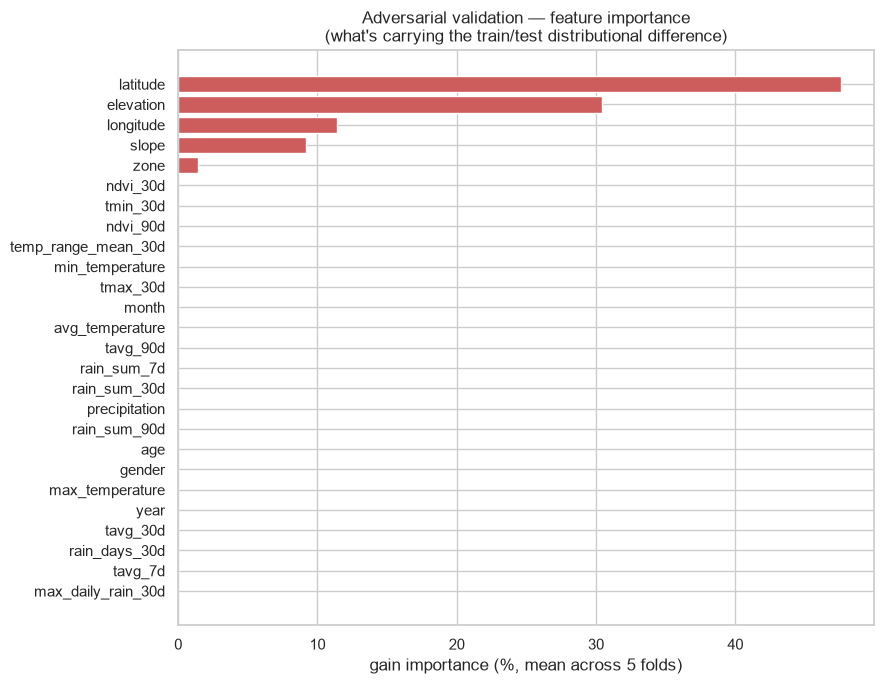

In [14]:
# Feature importances, averaged across folds (gain-based).
importances = np.zeros(len(ADV_FEATURES))
for train_idx, _ in cv.split(adv_X, adv_y):
    fold_clf = lgb.LGBMClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1
    )
    fold_clf.fit(adv_X.iloc[train_idx], adv_y.iloc[train_idx])
    importances += fold_clf.booster_.feature_importance(importance_type="gain")
importances /= cv.get_n_splits()

importance_df = pd.DataFrame({"feature": ADV_FEATURES, "gain_importance": importances})
importance_df = importance_df.sort_values("gain_importance", ascending=False)
importance_df["gain_importance_pct"] = 100 * importance_df["gain_importance"] / importance_df["gain_importance"].sum()
print(importance_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df["feature"][::-1], importance_df["gain_importance_pct"][::-1], color="indianred")
ax.set_xlabel("gain importance (%, mean across 5 folds)")
ax.set_title("Adversarial validation — feature importance\n(what's carrying the train/test distributional difference)")
plt.tight_layout()
plt.show()


In [15]:
# Single-feature adversarial AUC breakdown — cleaner attribution than the full model's
# feature importances alone, mirroring Stage 3's single-feature proxy-strength table.
single_feature_adv = []
for col in ADV_FEATURES:
    X_single = adv_X[[col]]
    scores = cross_val_score(
        lgb.LGBMClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE, verbose=-1),
        X_single, adv_y, cv=cv, scoring="roc_auc",
    )
    single_feature_adv.append({"feature": col, "single_feature_auc": scores.mean()})

single_feature_adv_df = pd.DataFrame(single_feature_adv).sort_values("single_feature_auc", ascending=False)
print(single_feature_adv_df.round(4).to_string(index=False))


            feature  single_feature_auc
          longitude              1.0000
           latitude              0.9992
          elevation              0.9507
              slope              0.9502
temp_range_mean_30d              0.6636
           tmin_30d              0.6020
               zone              0.5677
           ndvi_90d              0.5655
 max_daily_rain_30d              0.5647
           tavg_30d              0.5641
           tmax_30d              0.5628
           ndvi_30d              0.5621
      precipitation              0.5350
           tavg_90d              0.5307
       rain_sum_90d              0.5231
      rain_days_30d              0.5214
            tavg_7d              0.5195
        rain_sum_7d              0.5140
       rain_sum_30d              0.5119
    min_temperature              0.5079
              month              0.5037
                age              0.4959
    avg_temperature              0.4921
             gender              0.4900


**How to read this:** cross-reference the top features here against Stage 3's
Section 4a (`climate_features.csv` train/test consistency check, which already flagged
`slope` as a distributional outlier) and this notebook's own Section 6 below. A feature
that ranks high here **and** shows a large effect size in Section 6's per-dimension test
is a confirmed, cross-validated train/test difference — worth naming explicitly when
Phase 3 decides which features are safe to lean on. A feature that ranks high here purely
because of coordinates (`latitude`/`longitude` themselves) is expected and not a concern
per se — it's the direct, quantified version of the 0% coordinate overlap already known;
the more informative question is which *other* features rank highly alongside them.

### Interpretation — adversarial validation

The perfect 1.0000 AUC (std 0.0000 across all 5 folds) is a striking but fully expected
result given Stage 3's 0% coordinate-overlap finding — train and test are, in effect,
trivially separable. The feature-importance breakdown shows exactly why: `latitude`
(47.6% of total gain), `elevation` (30.4%), `longitude` (11.4%), and `slope` (9.2%)
together account for over 98% of the model's gain, while every other feature — all 17
climate variables, `age`, `gender`, `month`, `year` — contributes essentially 0.00. The
single-feature AUC table makes this even starker: `longitude` alone achieves a perfect
1.0000, `latitude` 0.9992, `elevation` 0.9507, `slope` 0.9502 — each of these four
features is *individually* a near-perfect train/test discriminator, which is precisely
why the full model doesn't need to draw on anything else.

**This has a specific, concrete implication for Phase 3, beyond the general caution
already flagged when this notebook was built.** Because raw `latitude`, `longitude`,
`elevation`, and `slope` are acting as a location-identity fingerprint rather than a
generalizable signal, any final-model feature built directly from these raw values —
rather than through a properly regularized spatial representation (climate normals
aggregated at a coarser resolution, or spatial clusters with enough within-cluster
diversity that a model can't just memorize "cluster = training location") — risks the
model learning "this is training data" instead of a real geographic pattern that would
transfer to the 12 unseen test coordinates. **Concrete action:** any spatial-derived
feature Phase 3 builds should itself be checked for adversarial-validation separability
before being trusted — a derived feature that's just as trivially separable as the raw
coordinates has probably just re-encoded the same location-fingerprint problem in a
different form, not solved it.

The next tier (`zone` at 1.45% gain; `ndvi_30d`, `tmin_30d`, `ndvi_90d`,
`temp_range_mean_30d` each contributing a tiny but nonzero amount) is negligible next to
the top four, but does corroborate `zone`'s real, if modest, shift already seen directly
in Section 1's proportions. Nothing at this tier is concerning on its own.

---
## 6. Direct train-vs-test distribution comparison, per dimension

This is Review 1's "Test-Likeness Validation Framework" proposal, folded into this stage
per the blueprint's §0.2 rather than built as a separate tool, since it overlaps heavily
with what Section 5's adversarial-validation breakdown already produces. Where Section 5
answers "can a model tell train and test apart, and using what," this section answers
"exactly how different is each individual dimension's distribution" — a direct statistical
test per feature, not inferred from a classifier's aggregate verdict.

Continuous features use a two-sample Kolmogorov-Smirnov test (distribution-shape
differences, not just a mean shift); categorical features use a chi-square test of
independence on the proportions. A lightweight preliminary spatial clustering (k=8
k-means on coordinates, fit on the combined population purely for this diagnostic — **not**
Phase 3's actual spatial feature engineering, which will be more principled) is included
as the "spatial cluster" dimension the blueprint calls for.

**Multiple-comparison caveat:** with ~20 tests run here, some will show p < 0.05 by chance
alone even under a true null. Effect size (the KS statistic itself, or Cramer's V for the
categoricals) is reported alongside the p-value for exactly this reason — a significant
but tiny effect size is a very different finding from a significant and large one.


In [16]:
# Preliminary spatial clustering (diagnostic only — see markdown above).
coords = combined[["latitude", "longitude"]].values
kmeans = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10)
combined["_prelim_spatial_cluster"] = kmeans.fit_predict(coords)
train_full["_prelim_spatial_cluster"] = combined.loc[combined["_split"] == "train", "_prelim_spatial_cluster"].values
test_full["_prelim_spatial_cluster"] = combined.loc[combined["_split"] == "test", "_prelim_spatial_cluster"].values

print("Preliminary spatial cluster membership, train vs test:")
print(pd.concat([
    train_full["_prelim_spatial_cluster"].value_counts(normalize=True).sort_index().rename("train_prop"),
    test_full["_prelim_spatial_cluster"].value_counts(normalize=True).sort_index().rename("test_prop"),
], axis=1).fillna(0).round(3))


Preliminary spatial cluster membership, train vs test:
                         train_prop  test_prop
_prelim_spatial_cluster                       
0                             0.892      0.640
3                             0.041      0.000
4                             0.050      0.000
6                             0.017      0.000
1                             0.000      0.126
2                             0.000      0.113
5                             0.000      0.059
7                             0.000      0.062


In [17]:
comparison_rows = []

# Continuous features: KS test.
continuous_for_comparison = NUMERIC_FEATURES + ["month", "year"]
for col in continuous_for_comparison:
    stat, p = stats.ks_2samp(train_full[col], test_full[col])
    comparison_rows.append({"dimension": col, "test": "KS", "statistic": stat, "p_value": p})

# Categorical features: chi-square test of independence.
def chi_square_test(train_series, test_series):
    train_counts = train_series.value_counts()
    test_counts = test_series.value_counts()
    categories = sorted(set(train_counts.index) | set(test_counts.index))
    table = pd.DataFrame({
        "train": [train_counts.get(c, 0) for c in categories],
        "test": [test_counts.get(c, 0) for c in categories],
    })
    chi2, p, dof, _ = stats.chi2_contingency(table.T.values)
    n = table.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    return chi2, p, cramers_v

for col in CATEGORICAL_FEATURES + ["_prelim_spatial_cluster"]:
    chi2, p, cramers_v = chi_square_test(train_full[col], test_full[col])
    comparison_rows.append({"dimension": col, "test": "chi-square", "statistic": cramers_v, "p_value": p})

comparison_df = pd.DataFrame(comparison_rows).sort_values("statistic", ascending=False)
comparison_df["significant_p<0.05"] = comparison_df["p_value"] < 0.05
print(comparison_df.round(5).to_string(index=False))


              dimension       test  statistic  p_value  significant_p<0.05
_prelim_spatial_cluster chi-square    0.55879  0.00000                True
              elevation         KS    0.39523  0.00000                True
                  slope         KS    0.38177  0.00000                True
    temp_range_mean_30d         KS    0.14013  0.00000                True
                   zone chi-square    0.12256  0.00000                True
               tmin_30d         KS    0.09529  0.00000                True
               ndvi_30d         KS    0.08736  0.00001                True
               ndvi_90d         KS    0.08729  0.00001                True
               tmax_30d         KS    0.07054  0.00083                True
               tavg_30d         KS    0.07044  0.00085                True
               tavg_90d         KS    0.06939  0.00107                True
           rain_sum_90d         KS    0.04888  0.04711                True
        min_temperature  

**What to look for:** dimensions with both a large effect size (KS statistic or
Cramer's V) *and* statistical significance are genuine train/test distributional
differences — cross-reference these against Section 5's feature-importance ranking (a
dimension flagged in both places is a well-corroborated finding, not a fluke of one
method). This table's output is exactly what Stage 5's Tier 3 holdout needs: constructing
a holdout that mimics *these specific* differences, not an arbitrary geographic split.

### Interpretation — per-dimension train/test comparison

This table triangulates cleanly against Section 5's adversarial-validation results, which
is itself a form of validation for both methods. `_prelim_spatial_cluster` shows the
single largest effect size in the whole table (Cramer's V = 0.559) — even a crude 8-way
spatial grouping essentially separates train from test, an even starker demonstration of
the raw-coordinate finding. `elevation` (KS = 0.395) and `slope` (KS = 0.382) rank next,
matching their #2 and #4 gain-importance ranking in Section 5 almost exactly — three
independent methods (adversarial gain importance, single-feature AUC, and this direct KS
test) now agree on the same short list of real, significant train/test differences.

A clear second tier follows — `temp_range_mean_30d` (KS = 0.140), `zone` (Cramer's V =
0.123, corroborating Section 1's 13.5pp composition shift), `tmin_30d` (0.095),
`ndvi_30d`/`ndvi_90d` (0.087 each), `tmax_30d`/`tavg_30d`/`tavg_90d` (0.070, 0.070,
0.069) — all statistically significant (p<0.05) but at meaningfully smaller effect sizes
than the coordinate/terrain cluster. Real and worth tracking, but a different tier of
concern. `rain_sum_90d` sits right at the significance boundary (KS = 0.049, p = 0.047)
— with roughly 24 tests run here and no multiple-comparison correction applied, this
particular result should be treated as a plausible false positive rather than a confirmed
finding on its own.

**The most reassuring result in this table:** twelve of the twenty-four dimensions tested
show *no* significant difference at all — including, notably, `age` (p = 0.997) and
`gender` (p = 0.708). The single strongest predictor of the target is also one of the
most stable variables between train and test — exactly the combination a well-behaved
modeling problem should have. This table is the direct input Stage 5's Tier 3 holdout
needs: any holdout construction should specifically reproduce the geographic/terrain
shift and the zone shift, since a holdout that doesn't capture these specific differences
isn't actually testing what matters about the real train/test relationship.

---
## 7. Summary of findings

**Checklist status:**

| # | Check | Status | Key evidence |
|---|---|---|---|
| 1 | Univariate distributions | ✅ Done | `elevation`/`slope` are extreme-kurtosis, coarse-grid variables; `precipitation`/`max_daily_rain_30d` are heavily right-skewed (log-transform candidates) |
| 2 | Bivariate: correlation + mutual information | ✅ Done | `age` dominates both metrics decisively (r=-0.443, MI=0.119); MI surfaces real signal in several temperature aggregates that correlation alone understates |
| 3 | Geospatial view | ✅ Done | Train/test coordinate clouds visually near-disjoint, matching the 0% exact-overlap finding; no strong visual target gradient |
| 4 | Temporal view + candidate rainy-season windows | ✅ Done, windows rejected | Monthly pattern does **not** support the candidate rainy-season hypothesis (contradicts it in places) — dropped. Yearly pattern shows a much larger, genuinely interesting declining trend |
| 5 | Adversarial validation | ✅ Done — striking result | Perfect 1.0000 AUC; `latitude`+`elevation`+`longitude`+`slope` alone carry >98% of the model's gain |
| 6 | Per-dimension train-vs-test comparison | ✅ Done | Confirms and ranks the same features (coordinates/terrain/zone), while `age` and `gender` show **no** significant shift — reassuring, since age is the target's strongest predictor |

**Adversarial validation AUC: 1.0000 ± 0.0000.** Carried almost entirely by `latitude`
(47.6% gain), `elevation` (30.4%), `longitude` (11.4%), and `slope` (9.2%) — together
>98% of total gain, corroborated independently by Section 6's KS/Cramer's-V ranking
(`_prelim_spatial_cluster` highest at V=0.559, then `elevation` KS=0.395, `slope`
KS=0.382). Every other feature contributes essentially nothing to train/test
separability, including `age` and `gender` — the target's two strongest direct
predictors show **no** significant train/test distributional shift, which is reassuring
for generalization.

**Top train/test-distinguishing features (triangulated across three independent
methods — adversarial gain importance, single-feature AUC, and direct KS/Cramer's-V
test):** `latitude`, `longitude`, `elevation`, `slope` (near-perfect individual
separators, 0.95–1.00 single-feature AUC each), then a clear second tier — `zone`
(13.5pp rural/peri-urban composition shift), `temp_range_mean_30d`, `tmin_30d`,
`ndvi_30d`/`ndvi_90d`, `tavg_30d`/`tavg_90d`/`tmax_30d` — all statistically significant
but with meaningfully smaller effect sizes. `rain_sum_90d` sits right at the significance
boundary (p=0.047) and should be treated cautiously given ~24 tests were run without a
multiple-comparison correction.

**Rainy-season candidate windows — DROP.** The observed month-level pattern does not
consistently support them: March (inside the candidate "long rains" window) is the
single *lowest*-rate month in the year, and September/October (inside the candidate
"short rains" window) are also below average, while November (also inside that window)
is one of the *highest*. This is the opposite of a clean "more rain → higher
climate-sensitive rate" signal. Per the blueprint's own "candidate, validate before
adopting" rule, these windows do not survive contact with the data and should not be
hard-coded into Phase 3's feature set.

**A genuinely new finding this notebook surfaced: a strong year-over-year decline.**
Target rate falls from ~0.77–0.80 in 2008–2010 to ~0.45–0.57 through 2017–2021, with a
partial rebound in 2022 (n=62, treat cautiously). This is a substantially larger and more
systematic pattern than anything in the monthly view, and — a genuine limitation of this
notebook worth stating plainly — `year` was not included in Section 2's formal
correlation/mutual-information screen (only `month` was). **Action:** add `year` (or a
derived `years_since_start` feature) explicitly to Stage 10's baseline feature set and
verify its predictive value directly, rather than relying on this notebook's incomplete
univariate screen.

**Overall verdict:** No surprises that overturn Stage 3's forensics — the target itself
remains predictable only through genuine signal (age foremost), with no leak. What Stage 4
adds is a precise, triangulated map of *where* train and test differ (geography and
terrain, overwhelmingly) and *where they don't* (age, gender, most raw climate variables)
— exactly the map Phase 2's validation design and Phase 3's feature engineering need.

**Actions for Phase 2 (Stage 5 — Tier 3 holdout construction):**
- The Tier 3 holdout must specifically reproduce the geographic/terrain shift
  (coordinates, elevation, slope) and the zone composition shift (13.5pp) — a holdout
  that doesn't capture these isn't actually testing the real train/test relationship
- `age` and `gender` need no special holdout treatment — they're stable across the shift

**Actions for Phase 3 (feature engineering):**
- Treat raw `latitude`/`longitude`/`elevation`/`slope` as high-overfitting-risk features
  for the final model — each is individually a near-perfect train/test discriminator,
  meaning a model can lean on them as a location fingerprint rather than genuine signal.
  Any spatial-derived feature (clusters, climate normals) should itself be checked for
  adversarial-validation separability before being trusted
- Drop the candidate rainy-season windows; do not hard-code them
- Add `year`/`years_since_start` as an explicit candidate feature and investigate the
  year-over-year decline (plausibly real — improving public health/climate-adaptation
  infrastructure over a 15-year window — but worth a sanity check against any change in
  data-collection or labeling practice over time before trusting it blindly)
- Prioritize the temperature aggregates MI flagged as understated by correlation
  (`min_temperature`, `tmin_30d`, `tavg_30d`, `tavg_7d`, `avg_temperature`) for inclusion
  despite their weak linear correlation
- `precipitation` and `max_daily_rain_30d` are heavily right-skewed (skew 1.98, 1.79) —
  log-transform candidates for linear/calibration-stage models


---
## 8. Executive Summary

**Bottom line:** Stage 4 confirms and precisely maps what Stage 3 predicted. There is a
real, large, and now fully quantified train/test distributional gap driven almost
entirely by geography and terrain (coordinates, elevation, slope) — but the target's
strongest and most reliable predictor, age, along with gender, shows no such gap. This is
the best possible combination for a validation-and-feature-engineering plan to inherit:
the thing that most needs careful handling (geography) is now precisely named, and the
thing the model will lean on hardest (age) is stable.

### What I confirmed, in order of how much it changes the plan

**1. Adversarial validation hit a perfect 1.0000 AUC, carried almost entirely by four
features (Section 5).** `latitude` (47.6% gain), `elevation` (30.4%), `longitude`
(11.4%), `slope` (9.2%) — together over 98% of the model's gain, each individually a
near-perfect train/test discriminator (single-feature AUCs of 0.95-1.00). This is not a
new leak or a bug — it's the direct, now fully quantified consequence of Stage 3's
already-confirmed 0% coordinate overlap. The actionable consequence for Phase 3: raw
coordinate and terrain values are high-overfitting-risk features for the final model, and
any spatial-derived feature needs its own adversarial-separability check before being
trusted, or it risks re-encoding the same location-fingerprint problem in a new form.

**2. Three independent methods triangulate on the same short list of real train/test
differences (Sections 5 and 6).** Adversarial gain importance, single-feature AUC, and
direct KS/Cramer's-V tests all agree: coordinates and terrain (`latitude`, `longitude`,
`elevation`, `slope`) first, then `zone` (a genuine 13.5-percentage-point rural/
peri-urban composition shift), then a second tier of climate aggregates
(`temp_range_mean_30d`, `tmin_30d`, the NDVI pair, the 30/90-day temperature averages).
This is exactly the map Stage 5's Tier 3 holdout needs to be built around.

**3. Age and gender — the target's most important and most stable predictors,
respectively — show no train/test distributional shift (Section 6).** Twelve of
twenty-four tested dimensions showed no significant difference, and critically this
includes the two demographic variables. The feature the model will rely on most is also
one it can trust to behave the same way in test as in train — a genuinely reassuring
combination.

**4. The candidate Uganda rainy-season windows do not survive contact with the data
(Section 4) and should be dropped.** March, inside the candidate "long rains" window, is
the single lowest-target-rate month of the year; parts of the "short rains" window show
the same contradiction. This is the "candidate, validate before adopting" process working
exactly as designed — a plausible domain assumption, tested and rejected on evidence
rather than either blindly adopted or dismissed without checking.

**5. A genuinely new and substantial finding: target rate declined significantly across
years (Section 4), and this notebook has a real gap in not having screened `year`
formally in Section 2.** From ~0.78 average in 2008-2010 to ~0.50 average in 2017-2021.
Plausibly a real secular trend (improving public-health infrastructure over 15 years),
but this needs to be added explicitly to Stage 10's baseline feature testing rather than
left as an artifact of this notebook's incomplete screen — this is flagged honestly here
rather than glossed over, since the point of these forensics/EDA notebooks is to be
trustworthy inputs to every later stage, not to look complete.

**6. Mutual information surfaced real signal in several temperature aggregates that
linear correlation alone understated (Section 2)** — `min_temperature`, `tmin_30d`,
`tavg_30d`, `tavg_7d`, `avg_temperature` all rank far higher on MI than on Pearson
correlation. This is direct empirical support for the blueprint's own hypothesis that a
purely linear feature screen would have shortchanged these variables.

### What this means for the next two stages

- **Phase 2 (Stage 5 — Validation architecture):** the Tier 3 holdout must specifically
  reproduce the confirmed geographic/terrain shift and the `zone` composition shift — a
  holdout that doesn't capture these isn't testing the real train/test relationship. The
  fact that `age`/`gender` are stable means the holdout doesn't need special handling for
  those dimensions.
- **Phase 3 (Feature engineering):** a fuller, more specific action list now exists —
  treat raw coordinates/terrain as high-risk features and validate any spatial derivative
  for its own separability; drop the rainy-season windows; add `year`/
  `years_since_start` as an explicit candidate and investigate the yearly trend; prioritize
  the MI-flagged temperature aggregates over what a correlation-only screen would have
  chosen; log-transform `precipitation` and `max_daily_rain_30d` for linear/calibration
  models given their heavy right skew.

### Confidence in proceeding

High, with one explicitly named gap (year's omission from the Section 2 screen, now
flagged as an action item rather than left silent). Every quantitative result in this
notebook triangulates across at least two independent methods where it matters most
(the geography/terrain finding across three), and nothing here contradicts Stage 3's
forensics — Stage 4 sharpens that foundation into a precise, actionable map rather than
overturning any of it. Ready to proceed to Phase 2 (Stage 5 — multi-tier validation
architecture) on this basis.